# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


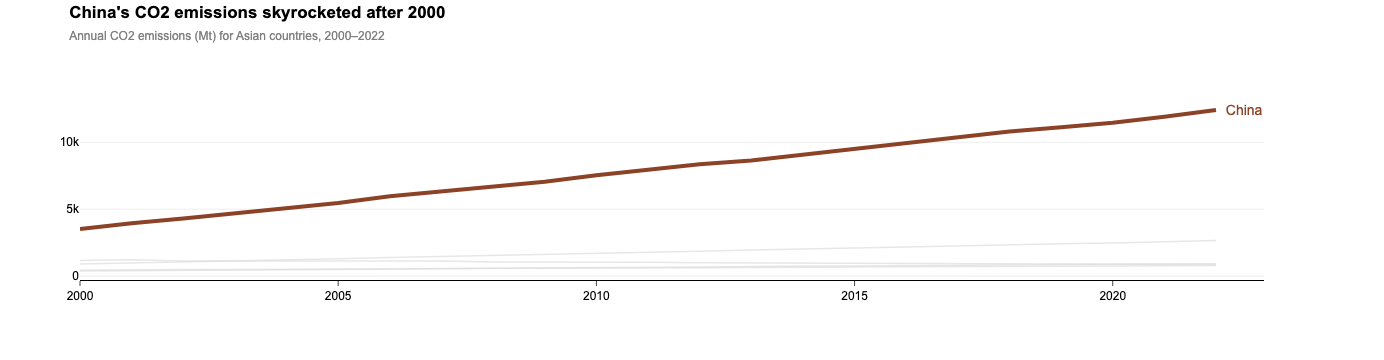

In [11]:
import plotly.graph_objects as go

df_asia = df[df['Region'] == 'Asia']
highlight_country = 'China'

style_highlight = {'color': '#8C4227', 'width': 4, 'opacity': 1}
style_background = {'color': '#DDDDDD', 'width': 1.5, 'opacity': 0.7}

fig = go.Figure()

for country in df_asia['Country'].unique():
    df_country = df_asia[df_asia['Country'] == country]
    
    is_highlight = (country == highlight_country)
    style = style_highlight if is_highlight else style_background

    fig.add_trace(go.Scatter(
        x=df_country['Year'],
        y=df_country['CO2_Mt'],
        mode='lines',
        name=country,
        line=dict(color=style['color'], width=style['width']),
        opacity=style['opacity'],
        hoverinfo='name+y'
    ))

last_row = df_asia[(df_asia['Country'] == highlight_country)].sort_values('Year').iloc[-1]

fig.add_annotation(
    x=last_row['Year'],
    y=last_row['CO2_Mt'],
    text=f"  {highlight_country}",
    showarrow=False,
    xanchor="left",
    font=dict(color=style_highlight['color'], size=14, family="Arial")
)

fig.update_layout(
    title={
        'text': f"<b>{highlight_country}'s CO2 emissions skyrocketed after 2000</b><br>"
                f"<span style='font-size:12px; color:grey;'>Annual CO2 emissions (Mt) for Asian countries, 2000–2022</span>",
        'x': 0.05,
        'y': 0.95
    },
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False, 
    margin=dict(r=120, t=100),
    font=dict(family="Arial", color="black")
)

fig.update_xaxes(showgrid=False, linecolor='black', ticks='outside')
fig.update_yaxes(showgrid=True, gridcolor='#EEEEEE', zeroline=False)

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


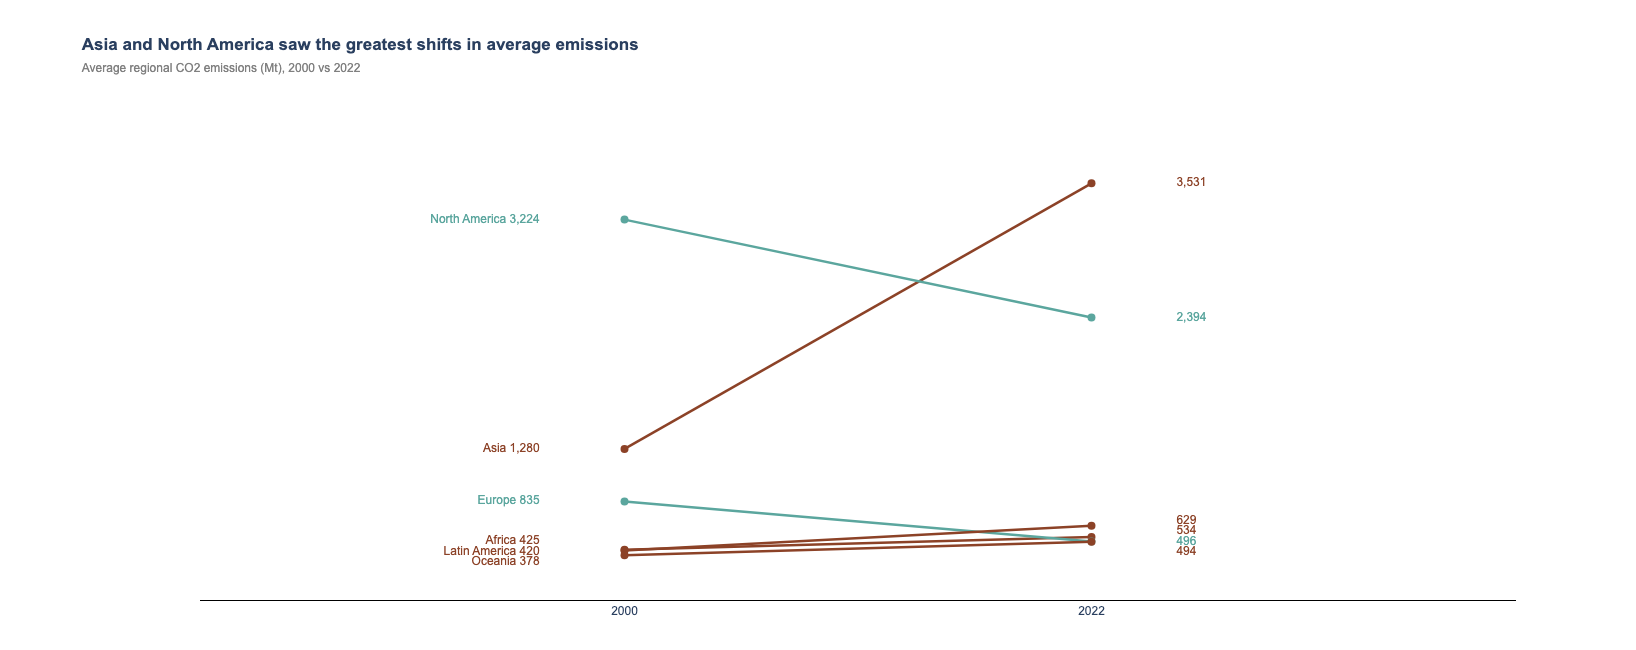

In [34]:
import plotly.graph_objects as go
import numpy as np

df_slope = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
df_slope = df_slope[df_slope['Year'].isin([2000, 2022])]

vals_2000 = dict(zip(df_slope[df_slope['Year']==2000]['Region'], 
                     df_slope[df_slope['Year']==2000]['CO2_Mt']))
vals_2022 = dict(zip(df_slope[df_slope['Year']==2022]['Region'], 
                     df_slope[df_slope['Year']==2022]['CO2_Mt']))

MIN_GAP = 90  

def spread_labels(val_dict, min_gap=MIN_GAP):
    """Nudge label y-positions apart if they're too close."""
    regions = sorted(val_dict.keys(), key=lambda r: val_dict[r])
    positions = {r: val_dict[r] for r in regions}
    
    for _ in range(50):
        changed = False
        sorted_regions = sorted(positions.keys(), key=lambda r: positions[r])
        for i in range(1, len(sorted_regions)):
            r_low  = sorted_regions[i-1]
            r_high = sorted_regions[i]
            gap = positions[r_high] - positions[r_low]
            if gap < min_gap:
                push = (min_gap - gap) / 2
                positions[r_low]  -= push
                positions[r_high] += push
                changed = True
        if not changed:
            break
    return positions

label_pos_2000 = spread_labels(vals_2000)
label_pos_2022 = spread_labels(vals_2022)

fig = go.Figure()

for region in vals_2000.keys():
    val_2000 = vals_2000[region]
    val_2022 = vals_2022[region]
    line_color = "#8C4227" if val_2022 > val_2000 else "#5BA69E"

    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[val_2000, val_2022],
        mode='lines+markers',
        name=region,
        line=dict(color=line_color, width=2.5),
        marker=dict(size=8),
        hoverinfo='skip'
    ))

    fig.add_trace(go.Scatter(
        x=[1996],
        y=[label_pos_2000[region]],
        mode='text',
        text=[f"{region} {val_2000:,.0f}"],
        textposition="middle left",
        textfont=dict(color=line_color, family="Arial", size=12),
        showlegend=False,
        hoverinfo='skip'
    ))

    fig.add_trace(go.Scatter(
        x=[2026],
        y=[label_pos_2022[region]],
        mode='text',
        text=[f"{val_2022:,.0f}"],
        textposition="middle right",
        textfont=dict(color=line_color, family="Arial", size=12),
        showlegend=False,
        hoverinfo='skip'
    ))

fig.update_layout(
    title={
        'text': "<b>Asia and North America saw the greatest shifts in average emissions</b><br>"
                "<span style='font-size:12px; color:grey;'>Average regional CO2 emissions (Mt), 2000 vs 2022</span>",
        'x': 0.05
    },
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False,
    font=dict(family="Arial", size=12),
    xaxis=dict(
        range=[1980, 2042],
        showgrid=False,
        zeroline=False,
        linecolor='black',
        tickvals=[2000, 2022],
        ticktext=['2000', '2022']
    ),
    yaxis=dict(
        showgrid=False,
        showticklabels=False,
        zeroline=False,
        range=[0, df_slope['CO2_Mt'].max() * 1.2]
    ),
    margin=dict(l=200, r=120, t=100, b=50),
    height=650
)

fig.show()